In [74]:
#Core imports
import os, requests, json, time, csv
from datetime import datetime
from pathlib import Path
import pandas as pd
import numpy as np

#Set 'True' for debug info
INFO_MODE = False

#US EIA API Access
API_KEY = os.environ.get("EIA_API_KEY", "mq7cQLfepEbZ674BT2NOHHvhMs0pzbglrXM3Gdfn")
BASE_URL = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

FREQUENCY = "hourly"
REGION = "MISO"
START = "2019-01-01T00"
END = "2019-01-03T00"

In [75]:
def fetch(frequency, region, start, end, length = 5000, session = None):
    frames = [] 
    offset = 0
    s = session or requests.Session()
    while True:
        params = {
            "api_key": API_KEY,
            "frequency": frequency,
            "start": start,
            "end": end,
            "offset": offset,
            "length": length,
            "data[0]": "value",
            "facets[type][0]": "D",
            "facets[respondent][0]": region,
            "sort[0][column]": "period",
            "sort[0][direction]" : "asc",
        }

        prepared = requests.Request("GET", BASE_URL, params = params).prepare()
        print("Fetching...", prepared.url)
        
        try:
            response = s.get(BASE_URL, params = params, timeout = 50)
            if not response.ok:
                print("HTTP", response.status_code, "-", response.reason)
                print("Body:", response.text[:500])
                break
            response.raise_for_status()
            data = response.json()
            resp = data.get("response", {})
            rows = data.get("response", {}).get("data", [])

        except Exception as e:
            print(f"Error fetching data from API.", e)
            return None

        if INFO_MODE:
            print(rows)
            print(resp)

        if rows and INFO_MODE:
            print("Sample keys:", list(rows[0].keys()))

        total = int(resp.get("total") or 0)

        if not rows:
                break
        
        if len(rows) <= 3:
            first = rows[0]
            if not isinstance(first, dict) or "period" not in first:
                print("API returned metadata instead of timeseries rows. Check params.")
                break

        df = pd.DataFrame(rows)
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna(subset=["value"])

        frames.append(df)
        offset += length
        
        if (total and offset >= total) or (len(rows) < length):
             break
        
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index = True)

In [76]:
def discover_available(frequency, region, start, end, length = 1000, session = None):
    s = session or requests.Session()
    params = {
        "api_key": API_KEY,
        "frequency": frequency,
        "start": start,
        "end": end,
        "offset": 0,
        "length": length,
        "data[0]": "value",
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
    }
    prepared = requests.Request("GET", BASE_URL, params=params).prepare()
    print("Discover URL:", prepared.url)
    r = s.get(BASE_URL, params=params, timeout=60)
    print("HTTP", r.status_code)

    if not r.ok:
        print("Body:", r.text[:500])
        return pd.DataFrame()
    
    payload = r.json()
    rows = payload.get("response", {}).get("data", [])
    df = pd.DataFrame(rows)

    if df.empty:
        print("Discovery returned 0 rows - try widening the window or removing frequency/type filters.")
        return df
    
    print("Sample keys:", list(df.columns))

    if "respondent" in df.columns:
        print("Top respondents:")
        print(df["respondent"].value_counts().head(15))

    if "type" in df.columns:
        print("Types present:", df["type"].unique())

    return df

In [77]:
if INFO_MODE:
    disc = discover_available(FREQUENCY, REGION, START, END)
    disc.groupby(["respondent","type"]).size().sort_values(ascending = False).head(20)
    disc_ = disc[(disc["respondent"] == REGION) & (disc["type"] == "D")]
    print(len(disc_))
    disc_.head()

In [78]:
#Load data into raw folder
##BASE_DIR = Path(__file__).resolve().parent.parent
##print(BASE_DIR)

output_path = Path("C:\\Users\\atmor\OneDrive\Desktop\Repositories\Prenergyze\data\\raw\EIA\MISO_DEMAND_2019-01-01T00_2025-09-20T00.csv")

##os.path.join(f"{BASE_DIR}","data", "raw", "EIA", "{REGION}_DEMAND_{START}_{END}.csv")

if output_path.exists():
    data = pd.read_csv(output_path)
    print(f"Loaded cache from {output_path} into dataframe.")

else:
    data = fetch(FREQUENCY, REGION, START, END)

    if INFO_MODE:
        print("Test rows:", len(data))
        print(data.head())

        print(data.shape)
        print(data.columns)

    #Load data into raw folder
    data.to_csv(output_path, index = False)

if INFO_MODE:
    ax = data.plot.line(figsize = (12,6))
    ax.set_title("Demand over time (FPL)")

Loaded cache from C:\Users\atmor\OneDrive\Desktop\Repositories\Prenergyze\data\raw\EIA\MISO_DEMAND_2019-01-01T00_2025-09-20T00.csv into dataframe.


period             0
respondent         0
respondent-name    0
type               0
type-name          0
value              0
value-units        0
dtype: int64


Text(0.5, 1.0, 'Demand over time (MISO)')

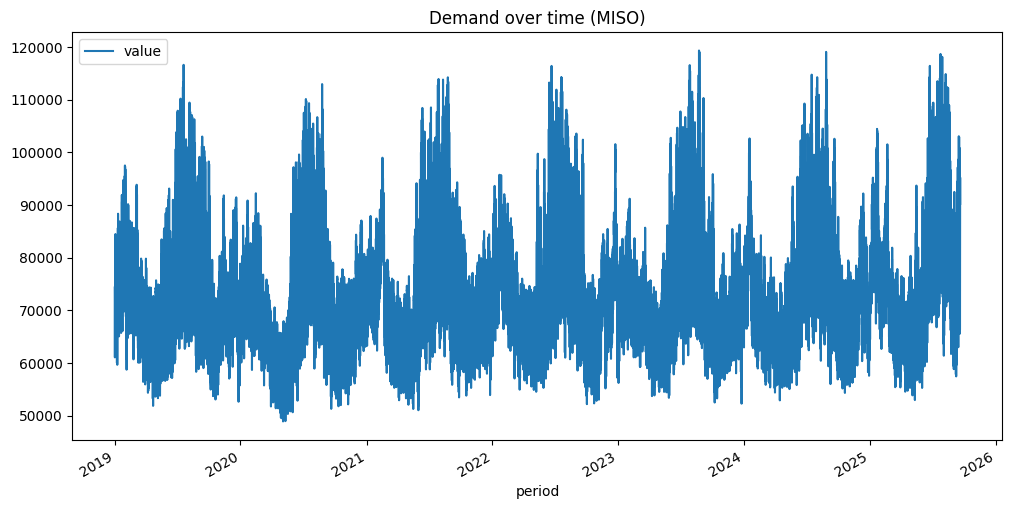

In [79]:
## Check missing values
print(data.isna().sum()) 

## Remove negatives
data.loc[data['value'] < 0, 'value'] = np.nan

## Handle outliers
mean = data['value'].mean()
std = data['value'].std()
z = (data['value'] - mean) / std
data.loc[abs(z) > 4, 'value'] = np.nan

## Convert period timestamps to DateTime object format
data['period'] = pd.to_datetime(data['period'], format="%Y-%m-%dT%H")  
data = data.set_index('period')

## Fill back
data['value'] = data['value'].interpolate(method="time")

ax = data.plot.line(figsize = (12,6))
ax.set_title("Demand over time (MISO)")